In [56]:
#         ____   _    _   ____     ____   ____       _  __  ____     _   ____   _    _   _    _
#        |  __| | |__| | |  _  \  |  __| |  __|     | |/ / |  _  \  | | |  __| | |__| | | \  | |
#        | |__  |  __  | | |_) /  | |__  | |__      | ' /  | |_) /  | | | |__  |  __  | |  \ | |       
#         ___ | | |  | | | | \ \  | |__  | |__      | . \  | | \ \  | |  __  | | |  | | | | \  |
#        |____| |_|  |_| |_|  \_| |____| |____|     |_|\_\ |_|  \_| |_| |____| |_|  |_| |_|  \_| 
#

#### **1. Import Libraries**

In [81]:
# Data Manipulation
import numpy as np
import pandas as pd

# Exploratory Data Analysis and Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Plot Decision Line
from mlxtend.plotting import plot_decision_regions

# Model persistence
import pickle
from pathlib import Path
import pickle


#### **2. Upload DataSet**

In [58]:
df = pd.read_csv(r"D:\Placement Predictor - PlaceAI\DataSet\engineering_student_placement_dataset.csv")

##### 2.1 Preview of DataSet

In [59]:
df.head()

,Index,IQ,CGPA,Placement
0,0,112,6.61,0
1,1,127,6.47,1
2,2,128,7.87,1
3,3,113,6.15,1
4,4,108,4.12,0


### **3. Preprocessing the Data**
#### Since We don't need Index column we remove that column [Feature Engineering]

In [60]:
df = df.iloc[:,1:]
df.head()

,IQ,CGPA,Placement
0,112,6.61,0
1,127,6.47,1
2,128,7.87,1
3,113,6.15,1
4,108,4.12,0


### **4. EDA**
#### We will polt the graph to identify the behaviour of dataset.

##### 4.1 Plotting Scatterplot to find Correlation between all the Numeric Columns.

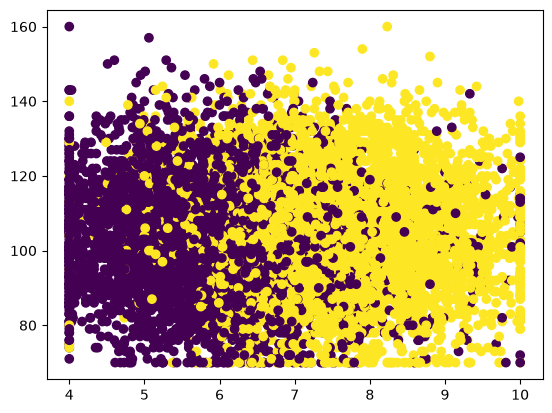

In [61]:
plt.scatter(df['CGPA'],df['IQ'],c=df['Placement'])

In [62]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [63]:
X  # X is DataFrame of input columns [IQ,CGPA]

,IQ,CGPA
0,112,6.61
1,127,6.47
2,128,7.87
3,113,6.15
4,108,4.12
...,...,...
9995,99,6.25
9996,120,9.04
9997,132,8.03
9998,86,5.99


In [64]:
y  # y is Series of output column[Placement]

0       0
1       1
2       1
3       1
4       0
       ..
9995    0
9996    1
9997    1
9998    1
9999    0
Name: Placement, Length: 10000, dtype: int64

##### 4.2 Plotting boxplot to Find out whether we have outliers or not?

<Axes: >

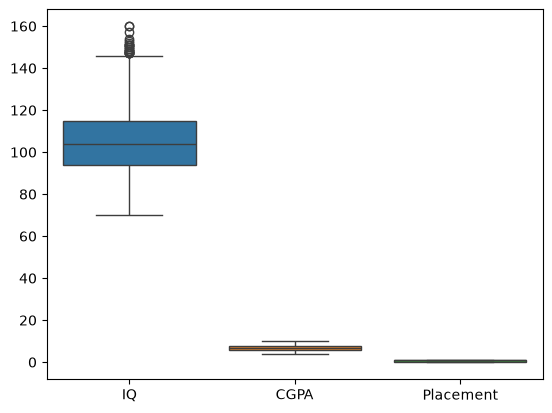

In [65]:
sns.boxplot(data=df)

##### There is some values in IQ ranging 140 to 160, which is <1% so that's natural. Rarely some students might have those extremely good IQ. So, NO need to worry about those outliers.

##### 4.3 Plotting Histogram

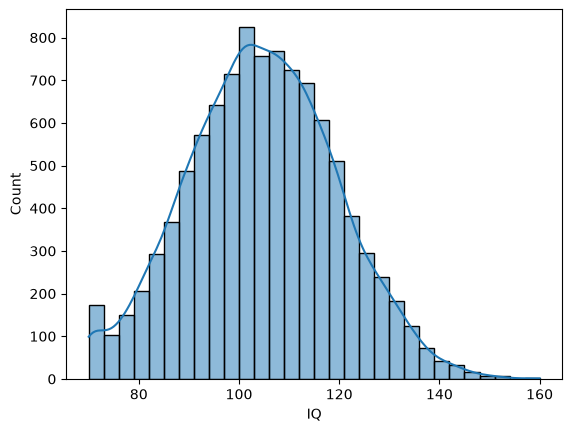

In [66]:
sns.histplot(df['IQ'], bins=30, kde=True)
plt.show()

### **5. Train test split**

In [67]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.03,random_state=42)

In [68]:
X_train

,IQ,CGPA
7093,105,7.41
1408,84,7.53
6690,116,7.75
3400,109,7.10
108,89,5.10
...,...,...
5734,89,6.83
5191,114,7.22
5390,88,7.51
860,110,7.34


In [69]:
y_train

7093    1
1408    1
6690    1
3400    1
108     0
       ..
5734    1
5191    1
5390    1
860     0
7270    1
Name: Placement, Length: 9700, dtype: int64

In [70]:
X_test

,IQ,CGPA
6252,121,5.21
4684,92,5.49
1731,96,4.21
4742,132,6.47
4521,99,5.85
...,...,...
6550,114,7.35
7642,116,7.32
6163,98,4.72
1494,92,7.57


### **6. Scale the Values and Train the Model**

In [71]:
clf = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

In [72]:
clf.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](2,)","['IQ','CGPA']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,2
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [73]:
y_pred = clf.predict(X_test)
print(y_pred)

[0 0 0 1 0 1 1 1 0 0 0 1 0 0 1 0 1 0 1 1 1 0 1 1 1 0 0 0 0 1 1 1 0 1 1 0 0
 0 1 0 1 1 1 0 1 1 1 0 1 1 1 1 0 0 0 1 1 1 0 0 1 0 0 0 1 1 0 0 0 0 1 1 1 1
 1 0 1 0 1 1 1 0 1 0 0 1 1 1 1 1 1 1 1 0 1 0 0 1 0 1 0 1 0 1 0 1 0 1 0 0 0
 1 0 1 0 0 0 1 0 1 1 1 1 0 1 1 1 1 1 1 0 1 0 0 0 1 0 0 0 0 1 1 1 0 1 1 1 0
 0 0 0 1 0 1 1 1 0 0 1 1 0 1 1 1 1 1 1 0 0 1 1 1 1 0 0 1 1 0 0 0 1 1 0 0 0
 1 1 1 0 1 1 1 0 0 1 1 1 0 1 1 1 1 1 0 1 0 1 1 1 1 0 1 0 0 0 0 0 1 0 0 1 0
 0 1 0 1 0 1 0 1 0 0 1 1 0 0 0 1 0 1 0 0 0 1 0 1 0 0 1 1 1 0 0 1 1 1 1 1 0
 0 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 1 0 1 0 1 0 0 1 0 1 1 1 1 0 0 1 1 0 0 1 1
 1 0 1 1]


In [74]:
y_test

6252    0
4684    0
1731    0
4742    1
4521    0
       ..
6550    1
7642    0
6163    0
1494    0
7695    1
Name: Placement, Length: 300, dtype: int64

### **7. Evaluation of the Model**


In [75]:
accuracy_score(y_test,y_pred)

0.8333333333333334

In [76]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.80      0.81       137
           1       0.83      0.87      0.85       163

    accuracy                           0.83       300
   macro avg       0.83      0.83      0.83       300
weighted avg       0.83      0.83      0.83       300



In [77]:
print(confusion_matrix(y_test, y_pred))

[[109  28]
 [ 22 141]]


### **8. Decision Line**

d:\Placement Predictor - PlaceAI\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


<Axes: >

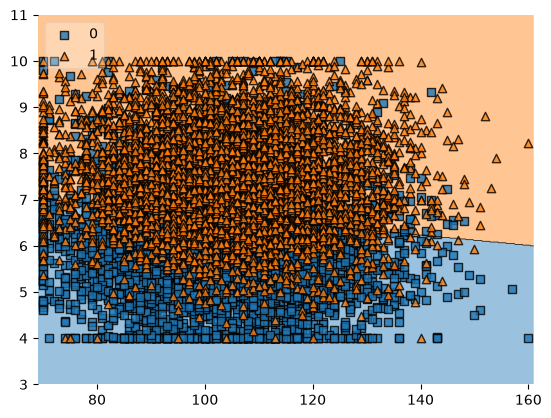

In [78]:
plot_decision_regions(X_train.values, y_train.values, clf=clf, legend=2)

### **9. Getting the Model**

In [82]:

model_dir = Path("../model")
model_dir.mkdir(exist_ok=True)

with open(model_dir / "model.pkl", "wb") as f:
    pickle.dump(clf, f)